# Продвинутый анализ моделей


|раздел | [nixtla](https://nixtlaverse.nixtla.io/statsforecast/) | [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|

https://otexts.com/fpppy/nbs/13-practical.html

## Импорт

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [31]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [32]:
from scipy import stats
import pmdarima as pm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.stattools import kpss

import statsmodels.api as sm

In [33]:
from pandas.tseries.frequencies import to_offset

In [34]:
from TSC_Nixtla_dump import *
plt_style_GOST()

In [35]:
from TSC_Nixtla_augmentation import *

In [36]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter("ignore", FutureWarning)

from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

In [37]:
from functools import partial

## Загрузка данных

Импорт данных аналогично предыдущего урока.

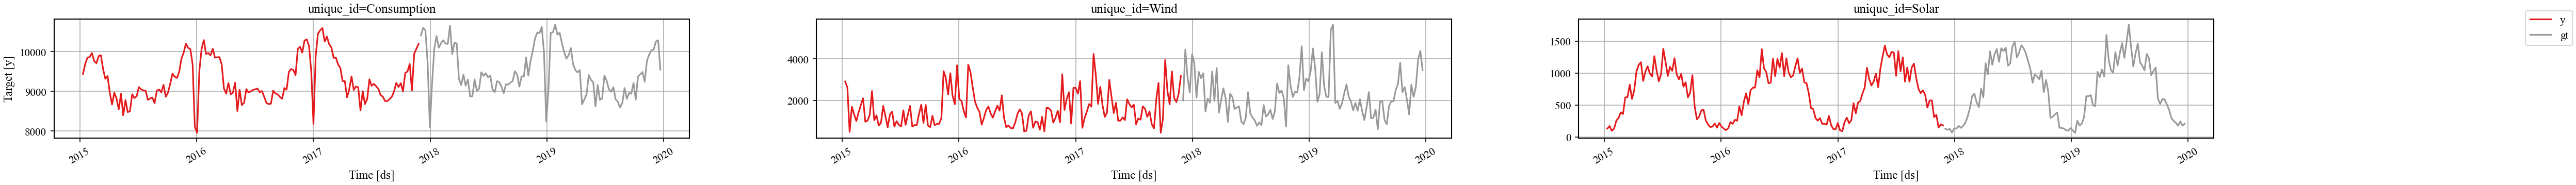

In [38]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']
y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series_v2(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1', n_cols = 3)

In [92]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    'CPSR':scaled_crps,
    'CI':coverage,
    'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Некоторые приемы аугментации данных

### Backcasting

In [93]:
BH = 3*SEASON
LEVEL = [90]
models = [
    ARIMA(order=(2, 1, 1), season_length=SEASON, seasonal_order=(0, 1, 1))
]

df_train_extended = backcast(
    df_train=df_train,
    models=models,
    h=BH,
    freq=FREQ,
    level=LEVEL
)

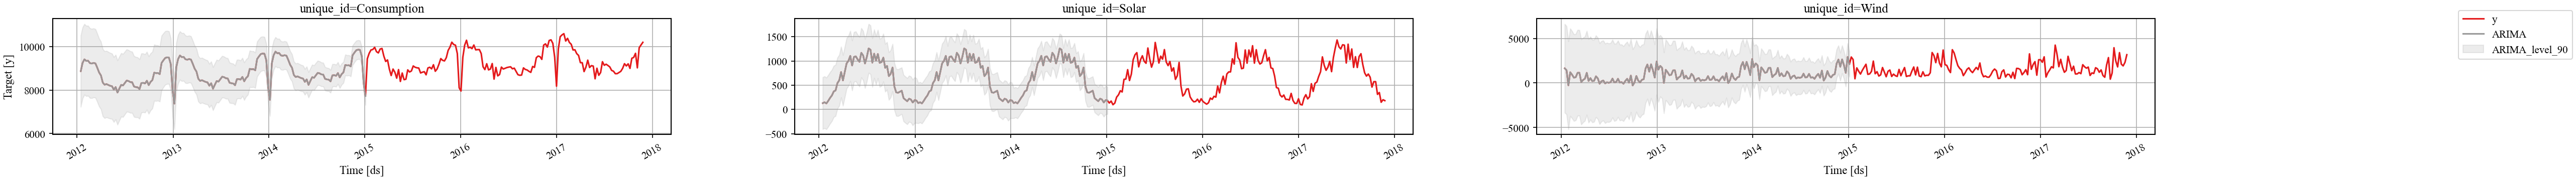

In [94]:
plot_series_v2( forecasts_df=df_train_extended, level=LEVEL[-1:],  palette='Set1', n_cols = 3)

#### Сравнение методов с и без расширения

##### С расширением  `backcast`

In [95]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    # MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),   
]

LEVELS = [90]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)
aliases = [model.alias for model in models]

In [96]:
fcst_sf = sf.forecast(df=df_train_extended, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train_extended,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)


metrics_sf_models = pd.concat({'with_backcast': metrics_sf_models}, axis=1)

metrics_sf_models.style.format('{:.2f}')

##### Без расширения

In [97]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models_ = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)

##### Сравним 2 модели по метрикам

In [98]:
metrics_sf_models_ = pd.concat({'GT': metrics_sf_models_}, axis=1)

metrics_sf_models = pd.concat([metrics_sf_models_, metrics_sf_models], axis=1)

metrics_sf_models.style.format('{:.2f}')

Результаты показывают некоторое снижение точеченых метрик при увеличении неопределенности прогноза. Хотя, при этом 95 и 5 хвосты предсказываются чуть лучше. coverage_level90 показывает ухудшение оценки интервалов.

#### Провека адекватности аугментации
##### Сравнения маргинальных распределений

Проверка адекватности аугментации начинается с сравнения маргинальных распределений исходного и синтетического рядов (без учета времени): если они статистически близки, аугментация не искажает базовые свойства данных.

* __нормализованное Wasserstein distance__ - сводная статистика, учиюывающая  форму, и сдвиг, измеряется в тех же единицах, что и данные.  Нормализация проводится к СКО. Интерпретация, если различия распределений сопостовимы с СКО, то имеют место существенные систематическом изменения в распределениях. 
* __KS statistic__ — сводная статистика Калмогорова-Смирнова для 2 двух распределений, учиюывающая максимальную (локальную) разницу параметров в гистограммах двух распределений. 
* __относительня mean_diff_pct__  — показывает смещение центра распределения (систематическое смещение).
* ____относительня std_diff_pct__ — показывает изменение разброса данных (систематическое изменение разброса данных).

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [86]:
n_backcast = len(df_train_extended) - len(df_train)
result = marginal_distribution_test(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,2309.4209,587.0692,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,59.4731,5.0000,0
3,backcasting,std_diff_pct,2.6514,10.0000,1


Результаты показывают что модель беккастинга воспроизводит только СКО оригинального ряда

##### Сравнение остатков

Отметим, что лучше проводить тесты после учета тренда и сезонности.

In [101]:
from statsforecast.feature_engineering import mstl_decomposition


mstl_model =  MSTL(season_length=[SEASON])

transformed_df, _ = mstl_decomposition(
    df_train,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df['residual'] = transformed_df['y']  - transformed_df['trend'] - transformed_df['seasonal'] 


transformed_df_extend, _ = mstl_decomposition(
    df_train_extended,
    model=mstl_model,
    freq=FREQ,
    h=1  # h=0 если только хотим декомпозицию
)
transformed_df_extend['residual'] = transformed_df_extend['y']  - transformed_df_extend['trend'] - transformed_df_extend['seasonal'] 

n_backcast = len(transformed_df_extend) - len(transformed_df)
result = marginal_distribution_test(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,wasserstein,159.5481,48.0477,0
1,backcasting,ks_pvalue,0.0000,0.0500,0
2,backcasting,mean_diff_pct,329.3915,5.0000,0
3,backcasting,std_diff_pct,72.9276,10.0000,0


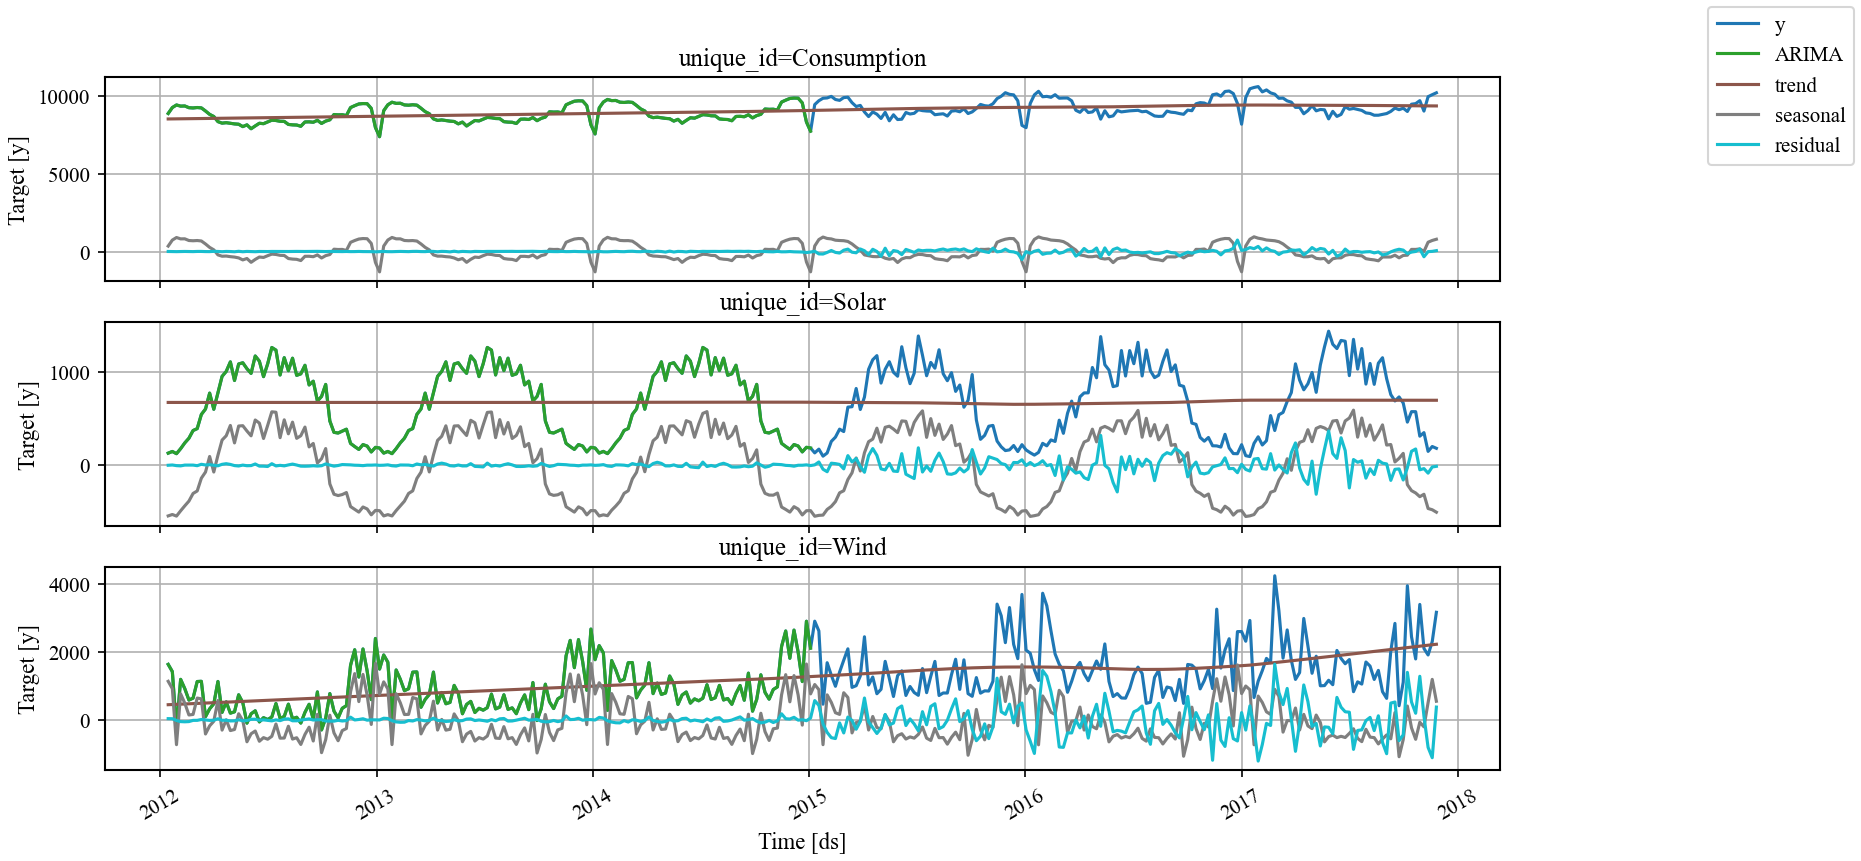

In [102]:
plot_series_v2(forecasts_df=transformed_df_extend)

Видно, что действительно тренд и остатки поменял форм.

##### Структурные тесты

Также проведем тесты 

* __ACF MAE__  — средняя ошибка между ACF оригинала и аугментации (проверяет сохранение временной структуры).
* __Spectral distance__ — расстояние Вассерштейна между спектрами мощности (проверяет сезонность).
* __Quantile coverage__  — сохаранение значений покрытия ключевых квантилей (10%, 50%, 90%).
* __Volatility correlation__ — корреляция скользящего стандартного отклонения (проверяет кластеризацию волатильности).

In [104]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(df_train['y'].values, df_train_extended.iloc[:n_backcast]['y'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0087,0.0500,1
1,backcasting,spectral_dist,0.0017,0.2000,1
2,backcasting,quantile_max_diff,1.8127,0.1500,0
3,backcasting,volatility_corr,0.1937,0.7000,0


In [105]:
n_backcast = len(df_train_extended) - len(df_train)
result = structural_tests(transformed_df['residual'].values, transformed_df_extend.iloc[:n_backcast]['residual'].values, name="backcasting")
result

,augmentation,metric,value,threshold,passed
0,backcasting,acf_mae,0.0878,0.0500,0
1,backcasting,spectral_dist,0.0453,0.2000,1
2,backcasting,quantile_max_diff,0.8187,0.1500,0
3,backcasting,volatility_corr,-0.4687,0.7000,0


Видно сохранение сезонной составляющей (ACF  и spectral_dist для обоих ВР), однако ни покрытие интервалов, ни гетероскедастичность не сохраняются

#### Упражение 
1. провести настройку  и  сравнение  различных методов для backcasting и их виляния на метрики
2. Провести анализ остатков предсказания с беккастингом и без него
3. Проведите backtesing (CV) с backcasting и без

### Стресс-тесты / аугментация искажениями

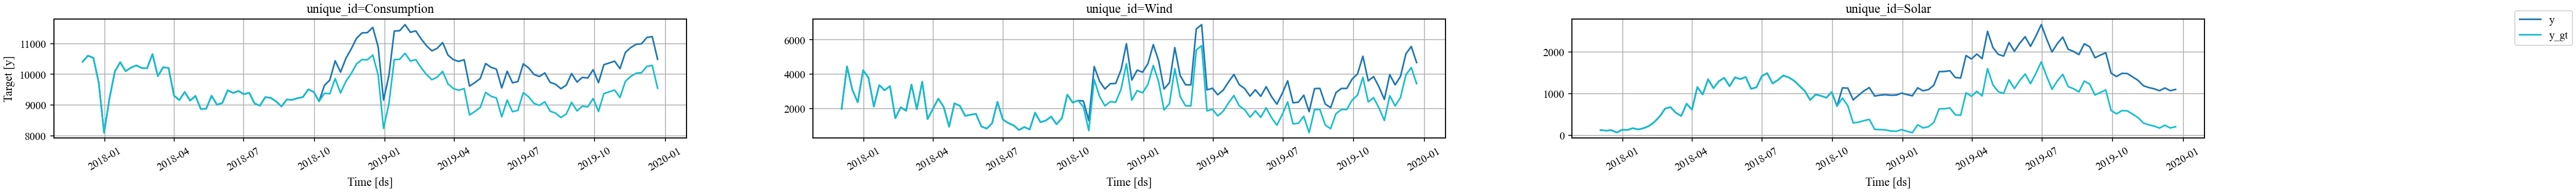

In [71]:
df_structural_shift = add_structural_shift_by_iqr(
    df_test.copy(), 
    start_date='2018-10-01', 
    shift_percent=100, 
    strategy='fast_saturation', 
    duration_offset='26W',
    freq=FREQ
)

# SWAP AND RENAME
df_structural_shift['y'], df_structural_shift['y_drift_fast_saturation'] = df_structural_shift['y_drift_fast_saturation'], df_structural_shift['y']
df_structural_shift = df_structural_shift.rename(columns={'y_drift_fast_saturation':'y_gt'})

plot_series_v2(forecasts_df=df_structural_shift, n_cols = 3)

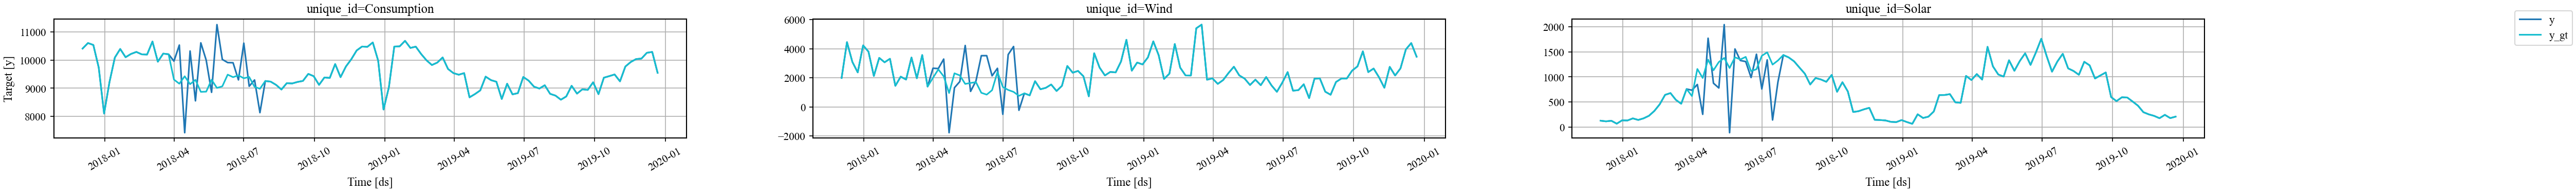

In [72]:
df_spike = add_local_volatility_spike(
    df_test,
    spike_start='2018-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

# SWAP AND RENAME
df_spike['y'], df_spike['y_volatility_spike'] = df_spike['y_volatility_spike'], df_spike['y']
df_spike = df_spike.rename(columns={'y_volatility_spike':'y_gt'})


plot_series_v2(forecasts_df=df_spike, n_cols = 3)

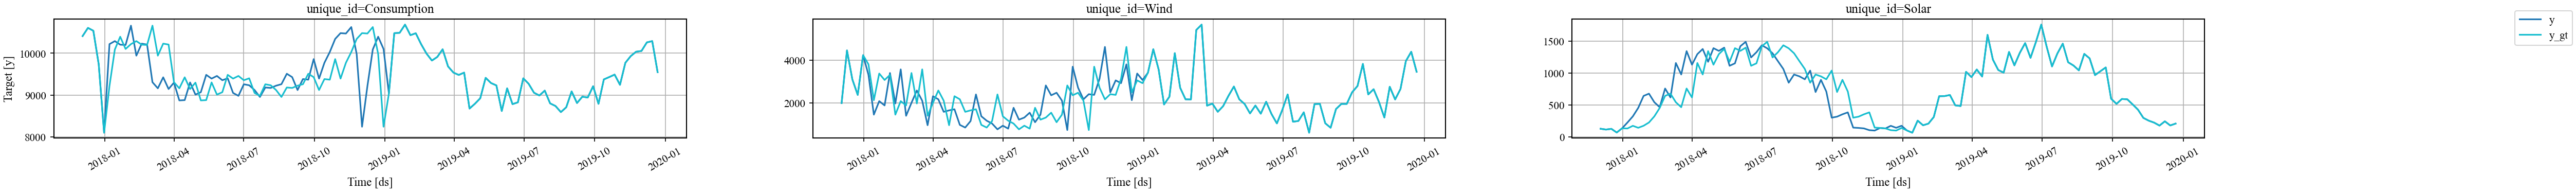

In [73]:
df_seasonal_shift = add_seasonal_phase_shift(
    df_test,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2018-01-01',
    duration_offset='1Y',
    freq=FREQ
)

# SWAP AND RENAME
df_seasonal_shift['y'], df_seasonal_shift['y_phase_shift'] = df_seasonal_shift['y_phase_shift'], df_seasonal_shift['y']
df_seasonal_shift = df_seasonal_shift.rename(columns={'y_phase_shift':'y_gt'})

plot_series_v2( forecasts_df=df_seasonal_shift, n_cols = 3)


In [74]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)
eval_sf = df_seasonal_shift.merge(fcst_sf, on=['unique_id', 'ds']).drop(columns='y_gt')

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)


metrics_sf_models.round(2).style.format('{:.2f}')

In [75]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=LEVELS,)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:],
).pivot(
    index='metric',
    columns='unique_id',
    values=aliases
)
metrics_sf_models.round(2).style.format('{:.2f}')

- Consumption и Solar стали менее надёжными в оценке неопределённости.
- Wind устойчив — возможно, его сезонность менее выражена или сдвиг не затронул ключевые фазы.
- Модели чувствительны к фазовому сдвигу сезонности — особенно ETS, который явно полагается на жёсткую сезонную структуру.

#### Упражнения
1. проверить разные комибнации аугменатций
2. проверить точность с комформным преобразованием
3. проверить точность с бектестинг

## Тюнинг

### Простое ансамблирование

#### Выбор моделей для ансамбля

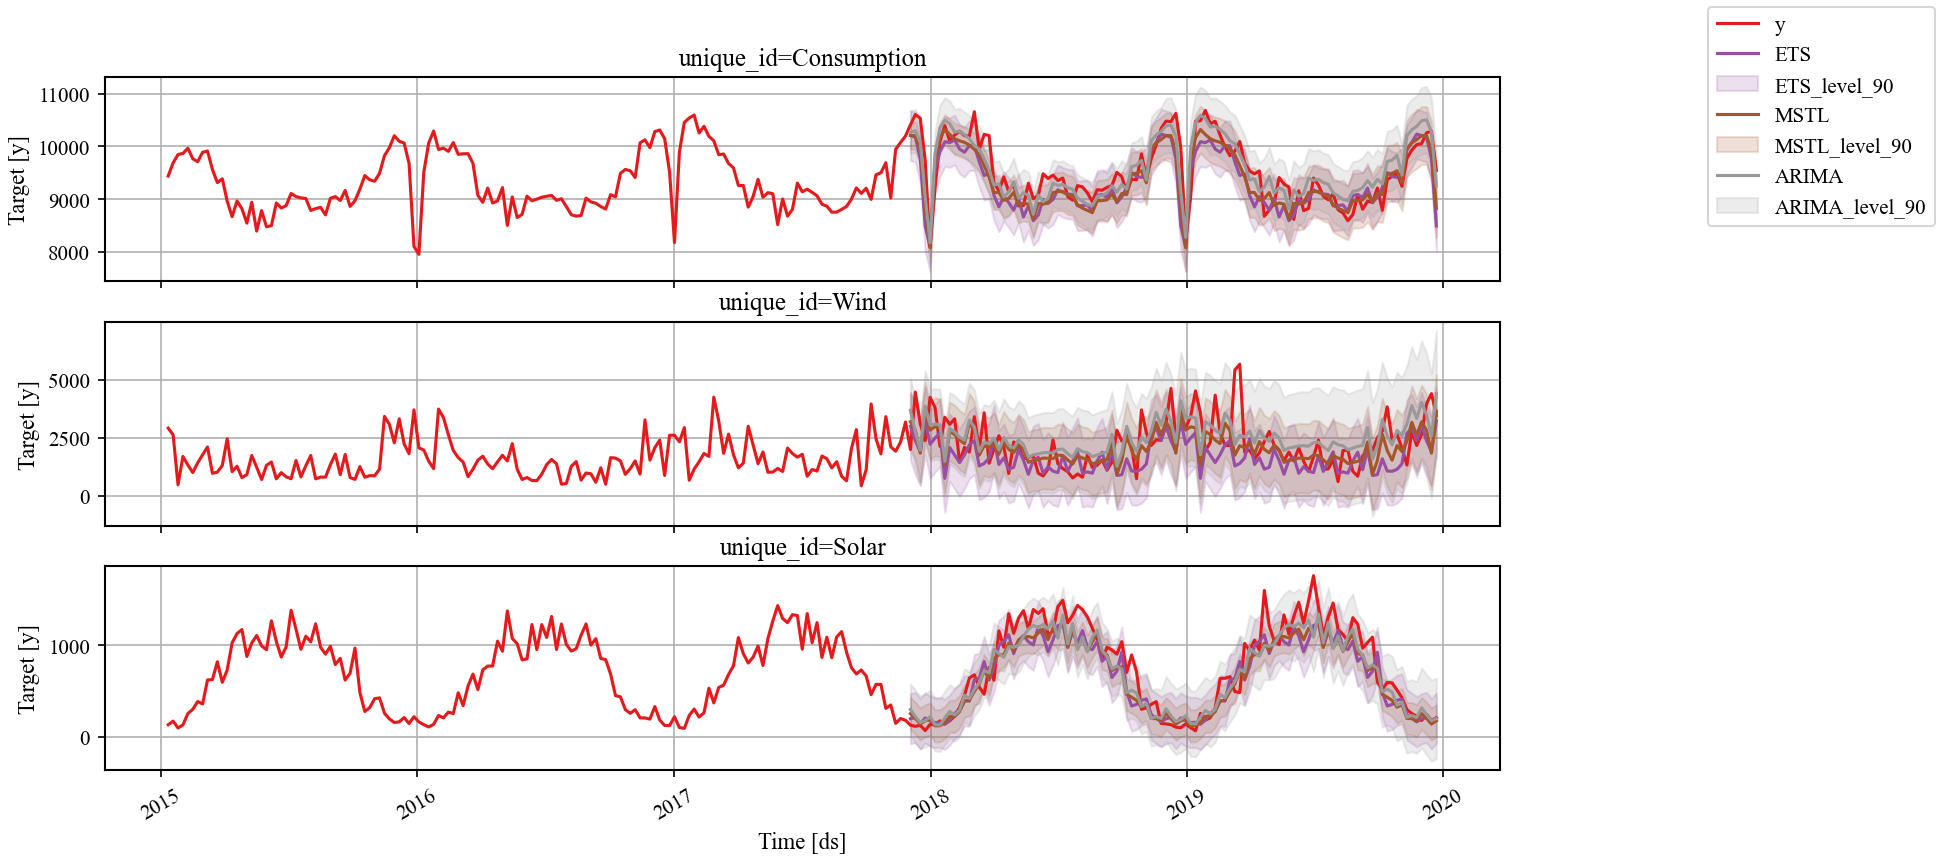

In [76]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]
aliases = [model.alias for model in models]
LEVELS = [90]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    palette='Set1',
)

#### Анcамбль путем сложения

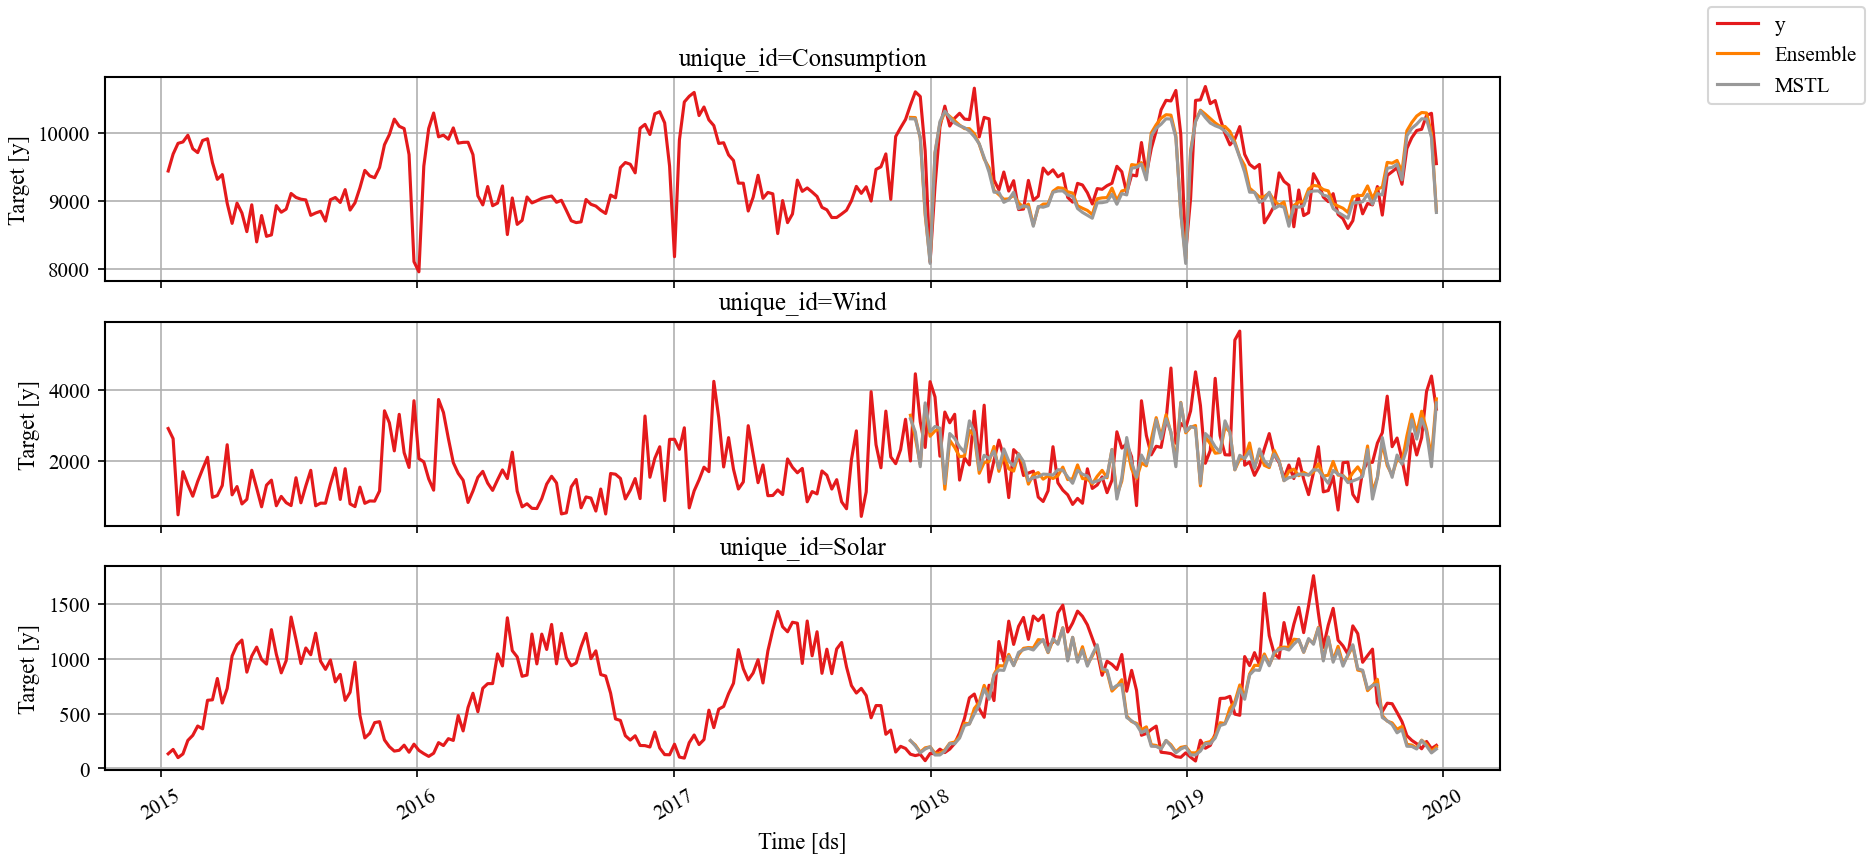

In [24]:
fcst_sf['Ensemble'] = fcst_sf[['ETS', 'MSTL', 'ARIMA']].mean(axis=1)


# Объединяем с тестом
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# Визуализация
plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['Ensemble',  'MSTL'],  # покажем сравнение
    # level=[90],
    palette='Set1',
)

#### Метрики

In [25]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics[:3],
    train_df=df_train,
    # level=LEVELS[-1:],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
metrics_sf_models.round(2).style.format('{:.2f}')

Как и ожидалось пдобный ансамбль лучше худших, но не лучше лучшего

#### Добавим интревалы наивным образом

In [26]:
# Квантили 90%
lo90_cols = [f"{name}-lo-90" for name in aliases if f"{name}-lo-90" in fcst_sf.columns]
hi90_cols = [f"{name}-hi-90" for name in aliases if f"{name}-hi-90" in fcst_sf.columns]


fcst_sf['Ensemble-lo-90'] = fcst_sf[lo90_cols].median(axis=1)
fcst_sf['Ensemble-hi-90'] = fcst_sf[hi90_cols].median(axis=1)


eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[-1:],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble']
)
metrics_sf_models.round(2).style.format('{:.2f}')

покрытие интервалов ведет себя точно также

#### Упражнение
1. проверить устойчивость ансамбля
2. проверить ансамбли, полученные медианной

### Взвешенный ансамбль

#### Квантильное взвешивание

Простое усреднение прогнозов не учитывает различия в качестве моделей и может ухудшать результат по сравнению с лучшей моделью (например, ARIMA показывала меньшую ошибку, чем невзвешенный ансамбль). Это связано с тем, что усреднение игнорирует вклад каждой модели в оценку неопределённости.

Одно из решений — использовать взвешенный ансамбль, где вес $ w_m $ модели $ m $ обратно пропорционален её ошибке. Наилучшей мерой ошибки для квантильных прогнозов является квантильный Loss.

Для квантиля уровня $ \alpha \in (0,1) $ вес модели определяется как:
$$
w_{m,\alpha} = \frac{1 / \left( \text{PL}_m(\alpha) + \varepsilon \right)}{\sum_{k=1}^M 1 / \left( \text{PL}_k(\alpha) + \varepsilon \right)},
$$
где $ \text{PL}_m(\alpha) = \frac{1}{N} \sum_{t=1}^N \ell_\alpha(y_t, \hat{q}_{t,\alpha}^{(m)}) $ — среднее значенвие квантильного Loss модели $ m $,  
$ \ell_\alpha(y, \hat{q}) = (y - \hat{q})(\alpha - \mathbb{I}\{y < \hat{q}\}) $ значенвие квантильного Loss модели $ m $ для квантиля $q$,  
а $ \varepsilon > 0 $ — малая константа для численной устойчивости.

Ансамблевый прогноз:
$$
\hat{q}_{t,\alpha}^{\text{ens}} = \sum_{m=1}^M w_{m,\alpha} \cdot \hat{q}_{t,\alpha}^{(m)}.
$$

In [27]:
alias = [model.alias for model in models]

LEVELS = [90, 95]

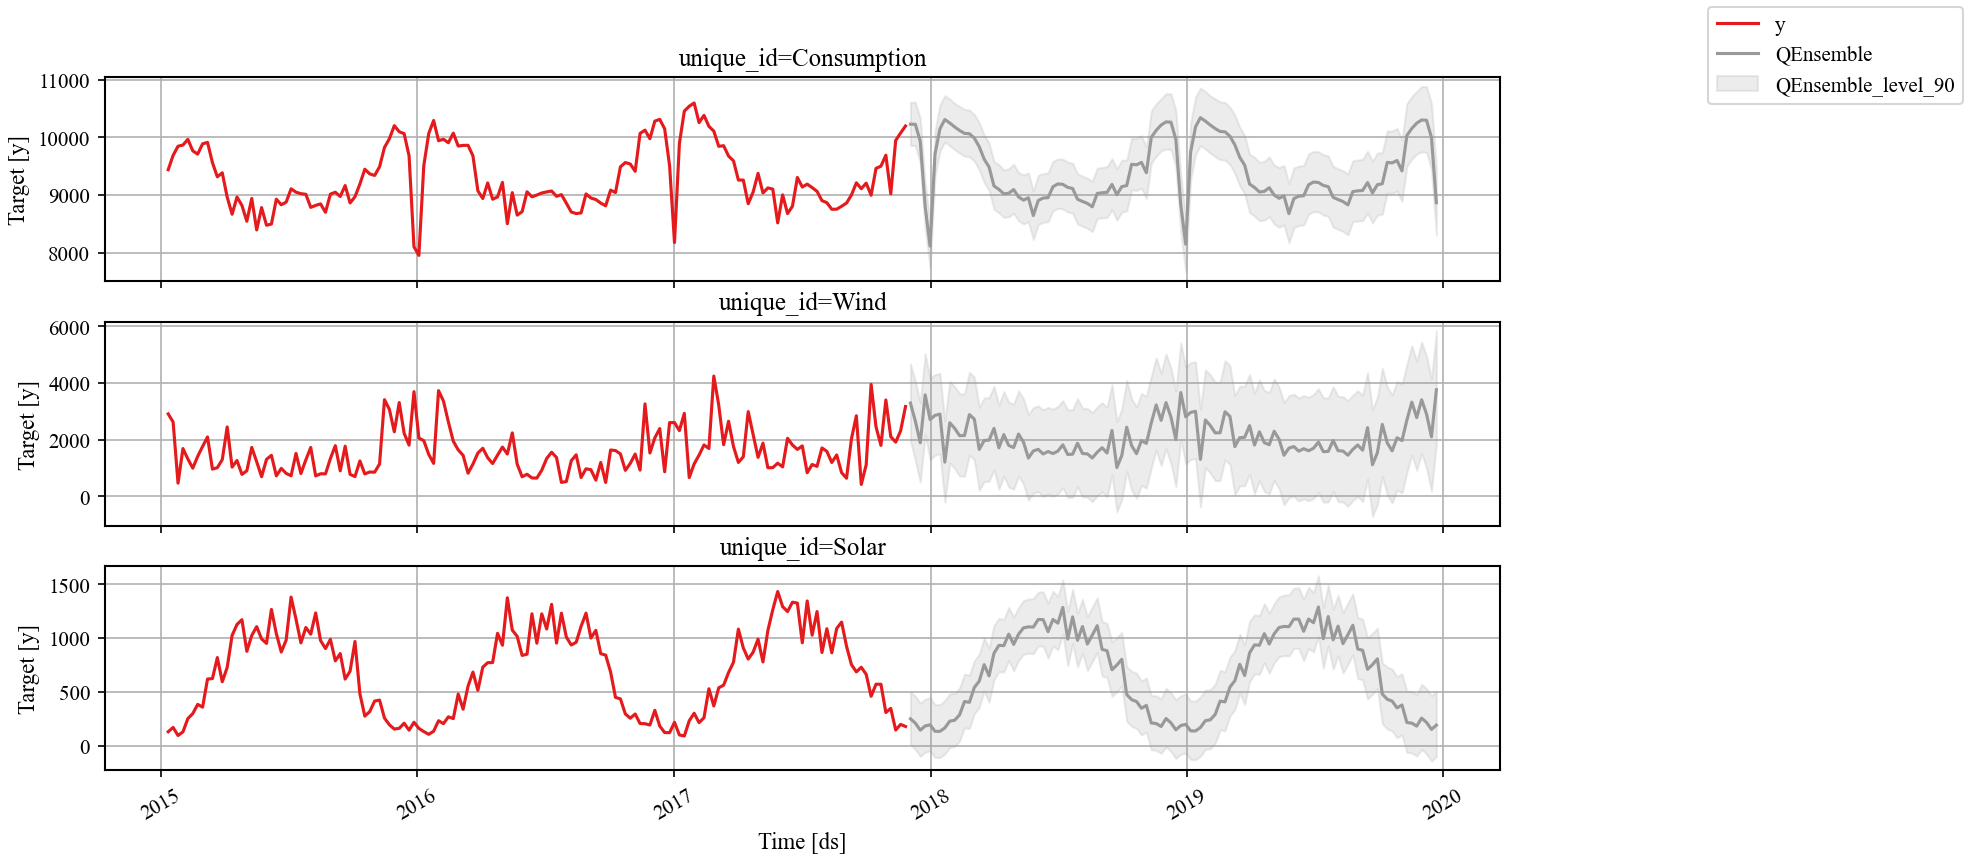

In [28]:
sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# Построить ансамбль
fcst_qensemble = quantile_ensemble_forecast(
    eval_df=eval_sf,
    model_names=alias,
    levels=LEVELS,          # или LEVELS
    target_col='y'
)
eval_sf = eval_sf.merge(fcst_qensemble, on=['unique_id', 'ds'])


# Визуализация — работает сразу
plot_series_v2(
    df_train,
    forecasts_df=fcst_qensemble,
    models=['QEnsemble'],
    level=LEVELS[:1],
    palette='Set1'
)

In [29]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS,
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'QEnsemble']
)
metrics_sf_models.round(2).style.format('{:.2f}')

### Взвешивание с весом по метрикам



Аналогично квантильному ансамблю можно получить ансамбль по любой другой метрике. Проверим, например, каким будет ансамбль по предсказанию всего распределения (метрика CRPS).

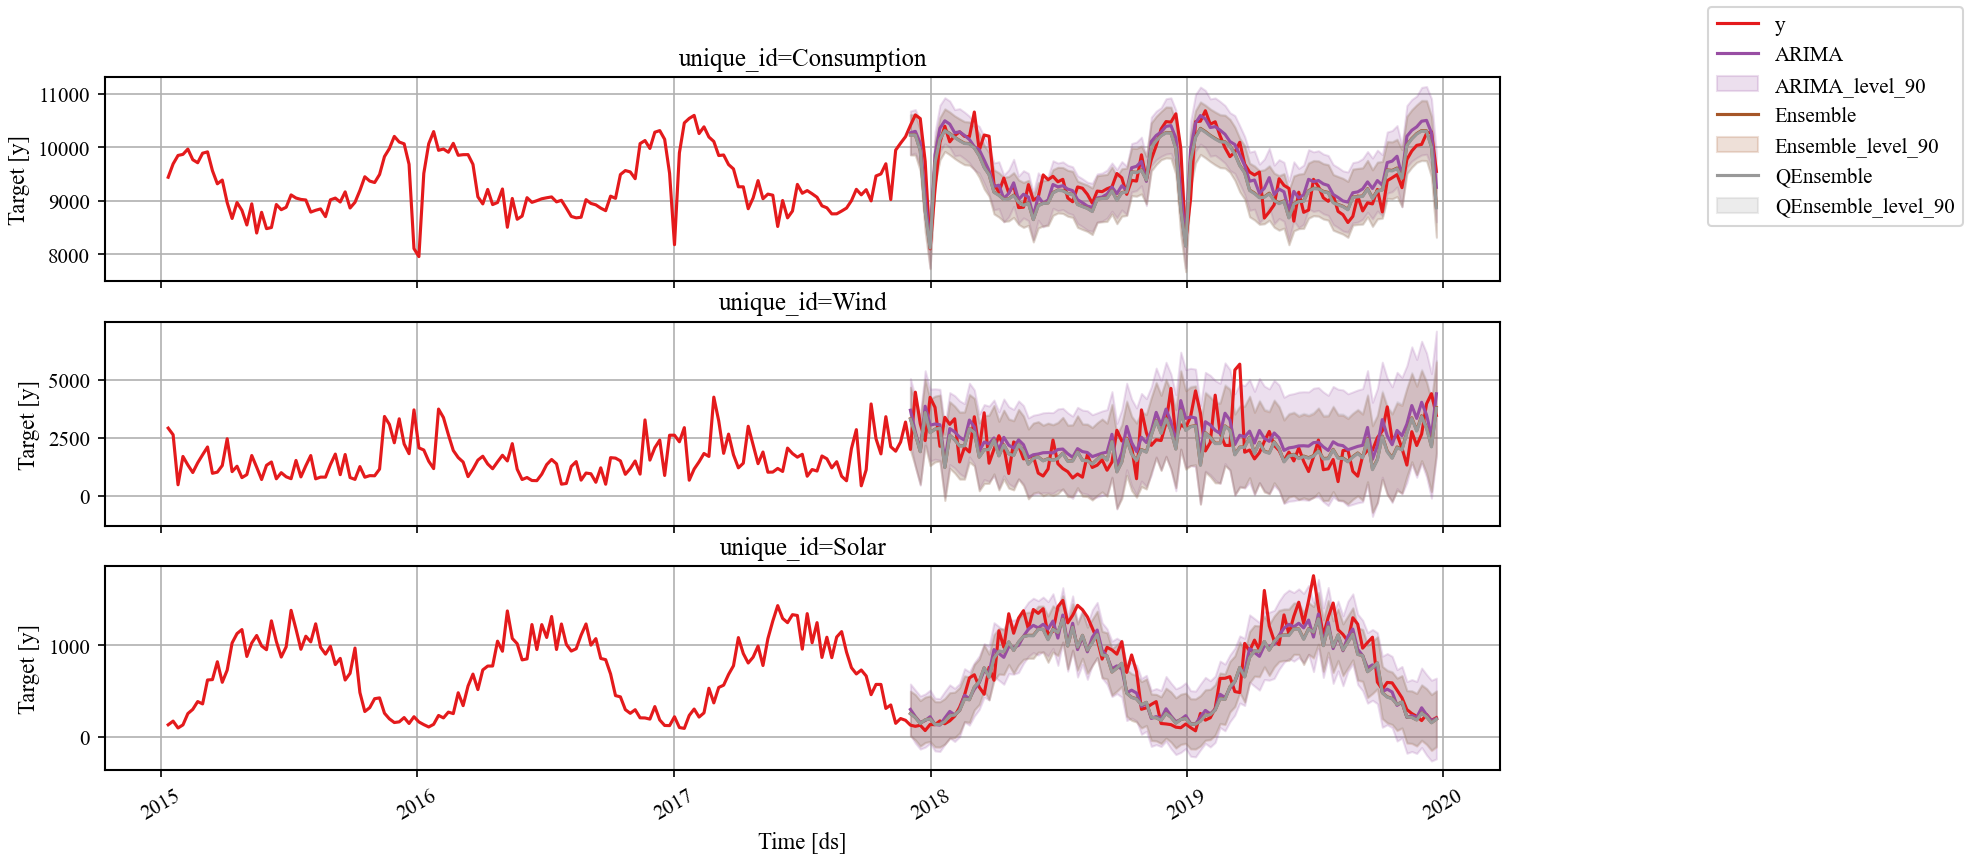

In [30]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=[90])
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_ensemble = metric_weighted_ensemble(
    forecasts_df=fcst_sf,
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90]),
    model_names=alias,
    levels=LEVELS,
    metric_name='scaled_crps'
)


eval_sf = eval_sf.merge(fcst_ensemble, on=['unique_id', 'ds'])
eval_sf = eval_sf.merge(fcst_qensemble, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df=eval_sf,
    models=['ARIMA', 'Ensemble', 'QEnsemble'],
    level=LEVELS[:1],
    palette='Set1'
)

In [31]:
metrics_sf_models = evaluate(
    df=eval_sf,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values=[*aliases, 'Ensemble', 'QEnsemble']
)
metrics_sf_models.round(2).style.format('{:.2f}')

### Веса в ансамбле

#### Получим веса для разных подходов

Можно построить ансамбли для различных метрик, которые мы используем. Получим их названия

In [32]:
metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90])
metrics_df['metric'].unique()

array(['mase', 'rmse', 'smape', 'scaled_crps', 'coverage_level90'],
      dtype=object)

Проверим, что для разных метрик разные веса

In [33]:
fcst_ensemble, weight_dict = metric_weighted_ensemble(
    forecasts_df=fcst_sf,
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90]),
    model_names=alias,
    levels=[90],
    metric_name='rmse',
    return_weights=True
)
weight_dict

{'ETS': 0.29207188414996055,
 'MSTL': 0.3529852602398135,
 'ARIMA': 0.3549428556102259}

In [34]:
fcst_ensemble, weight_dict = metric_weighted_ensemble(
    forecasts_df=fcst_sf,
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90]),
    model_names=alias,
    levels=[90],
    metric_name='coverage_level90',
    return_weights=True
)
weight_dict

{'ETS': 0.3388189374892903,
 'MSTL': 0.3624251746238547,
 'ARIMA': 0.29875588788685487}

#### Построение ансамбля с весами

In [35]:
weight_dict = {'ETS': 0.2,
                 'MSTL': 0.3,
                 'ARIMA': 0.5}

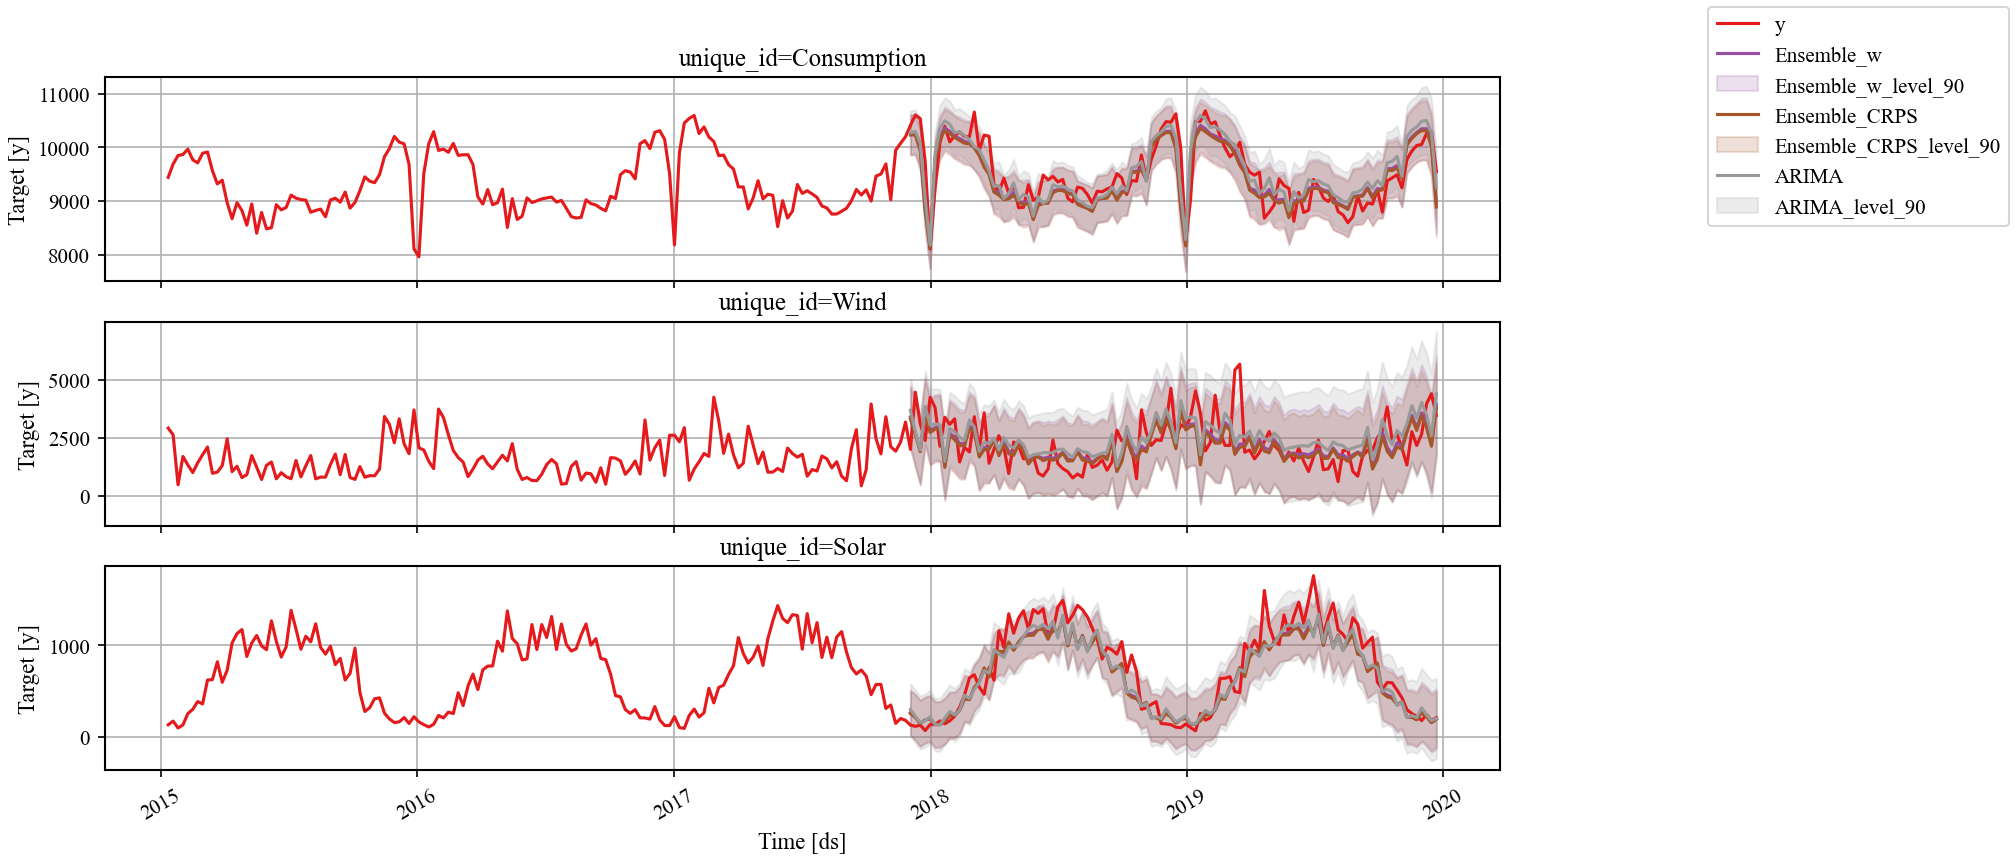

In [37]:
fcst_sf = sf.forecast(df=df_train, h=FH, level=[90])
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

fcst_ensemble_CI = metric_weighted_ensemble(
    forecasts_df=fcst_sf,
    metrics_df=evaluate(df=eval_sf, metrics=metrics, train_df=df_train, level=[90]),
    model_names=alias,
    levels=[90],
    ensemble_name = 'Ensemble_CRPS',
    metric_name='scaled_crps'
)

eval_sf = eval_sf.merge(fcst_ensemble_CI, on=['unique_id', 'ds'])


fcst_ensemble_  = vanilla_ensemble(
    forecasts_df=fcst_sf,
    aliases=alias,
    levels=[90],
    weights = weight_dict,
    ensemble_name = 'Ensemble_w',
)

fcst_ensemble = df_test.merge(fcst_sf, on=['unique_id', 'ds']).merge(fcst_ensemble_, on=['unique_id', 'ds']).merge(fcst_ensemble_CI, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df=fcst_ensemble,
    level=[90],
    models = ['Ensemble_w', 'Ensemble_CRPS', 'ARIMA' ],
    palette='Set1'
)


In [38]:
metrics_sf_models = evaluate(
    df=fcst_ensemble,
    metrics=metrics,
    train_df=df_train,
    level=LEVELS[:1],
).pivot(
    index='metric',
    columns='unique_id',
    values= get_aliases(fcst_ensemble)
)
metrics_sf_models.round(2).style.format('{:.2f}')

## Обнаружение аномальных данных

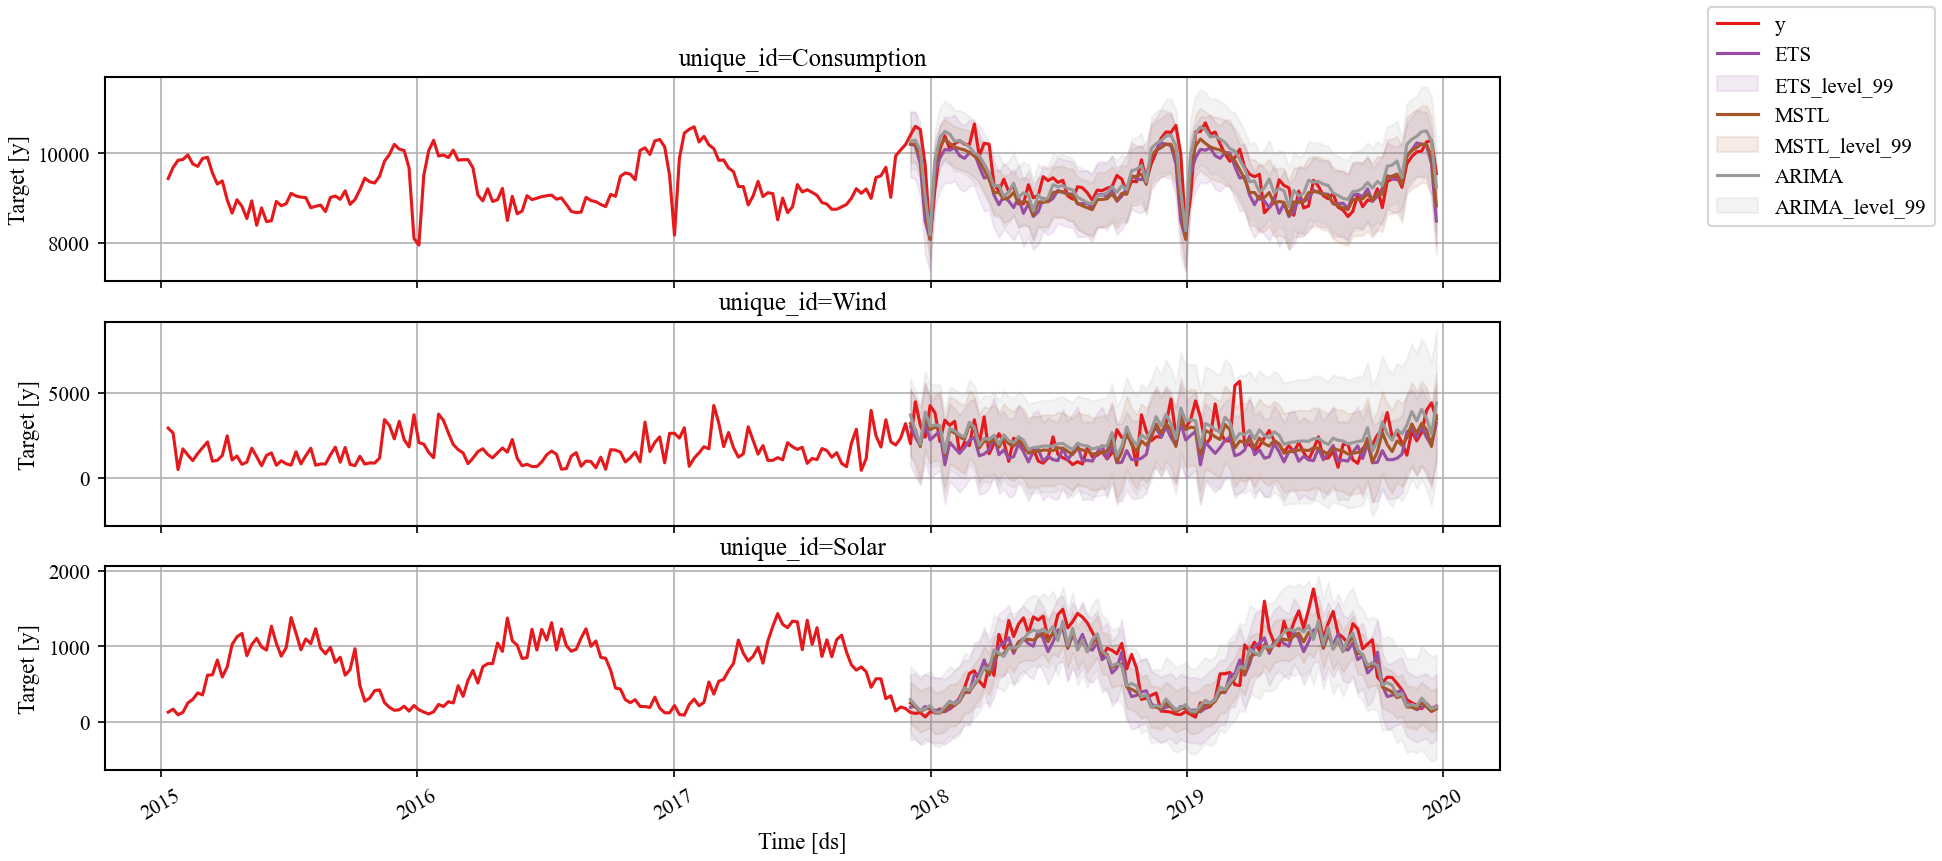

In [40]:
models = [
    AutoETS(season_length=SEASON, model='ZZA', damped = False, alias='ETS'),
    MSTL(season_length=SEASON, ),
    # TBATS(SEASON, use_trend = True, use_damped_trend = True),
    ARIMA(order=(3, 1, 1),
                season_length = SEASON,
                seasonal_order = (0, 1, 1,)  )
    
]
aliases = [model.alias for model in models]
LEVELS = [95, 99]

sf = StatsForecast(
    models=models,
    freq=FREQ,
)

fcst_sf = sf.forecast(df=df_train, 
                      h=FH, 
                      level=LEVELS,
                      fitted=True
                     )
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

plot_series_v2(
    df_train,
    forecasts_df = eval_sf,
    level=LEVELS[-1:],
    palette='Set1',
)

In [41]:
insample_forecasts = sf.forecast_fitted_values()
# insample_forecasts.head()

,unique_id,ds,y,ETS,ETS-lo-99,ETS-lo-95,ETS-hi-95,ETS-hi-99,MSTL,MSTL-lo-99,MSTL-lo-95,MSTL-hi-95,MSTL-hi-99,ARIMA,ARIMA-lo-99,ARIMA-lo-95,ARIMA-hi-95,ARIMA-hi-99
0,Consumption,2015-01-11,9440.105,9532.139116,8802.593987,8977.023847,10087.254386,10261.684245,9393.007101,8997.231693,9091.859217,9694.154986,9788.782509,9434.654755,8811.070771,8960.165957,9909.143553,10058.238739
1,Consumption,2015-01-18,9689.010,9859.492653,9129.947524,9304.377383,10414.607922,10589.037782,9849.421070,9453.645663,9548.273186,10150.568955,10245.196478,9686.379775,9062.795791,9211.890977,10160.868573,10309.963759
2,Consumption,2015-01-25,9847.035,10052.036055,9322.490926,9496.920785,10607.151324,10781.581184,9976.629985,9580.854577,9675.482100,10277.777869,10372.405392,9845.179557,9221.595573,9370.690759,10319.668355,10468.763541
3,Consumption,2015-02-01,9867.317,10046.977680,9317.432551,9491.862411,10602.092950,10776.522809,9855.569323,9459.793916,9554.421439,10156.717208,10251.344731,9865.916149,9242.332165,9391.427351,10340.404947,10489.500133
4,Consumption,2015-02-08,9966.415,10119.065500,9389.520371,9563.950230,10674.180769,10848.610629,9793.641430,9397.866023,9492.493546,10094.789315,10189.416838,9965.207870,9341.623886,9490.719072,10439.696668,10588.791854


In [42]:
anomalies = insample_forecasts[~insample_forecasts['y'].between(insample_forecasts['MSTL-lo-99'], insample_forecasts['MSTL-hi-99'])]
# anomalies.head()

,unique_id,ds,y,ETS,ETS-lo-99,ETS-lo-95,ETS-hi-95,ETS-hi-99,MSTL,MSTL-lo-99,MSTL-lo-95,MSTL-hi-95,MSTL-hi-99,ARIMA,ARIMA-lo-99,ARIMA-lo-95,ARIMA-hi-95,ARIMA-hi-99
50,Consumption,2015-12-27,8106.565,8427.462187,7697.917058,7872.346918,8982.577457,9157.007316,8717.428300,8321.652892,8416.280416,9018.576184,9113.203708,8107.600383,7484.016399,7633.111585,8582.089181,8731.184367
102,Consumption,2016-12-25,9513.222,8413.579660,7684.034531,7858.464390,8968.694929,9143.124789,8891.184984,8495.409576,8590.037100,9192.332868,9286.960392,8357.197688,7733.613704,7882.708890,8831.686486,8980.781672
220,Solar,2016-05-08,1374.571,1043.070941,616.962855,718.842739,1367.299143,1469.179028,1062.014713,787.897400,853.437203,1270.592222,1336.132025,1053.171974,624.729955,727.167869,1379.176079,1481.613993
224,Solar,2016-06-05,851.244,1208.413380,782.305294,884.185179,1532.641582,1634.521467,1134.713967,860.596654,926.136457,1343.291476,1408.831279,1165.292997,736.850978,839.288892,1491.297102,1593.735015
272,Solar,2017-05-07,779.076,1061.664269,635.556182,737.436067,1385.892470,1487.772355,1058.985417,784.868105,850.407908,1267.562926,1333.102730,1308.513101,880.071083,982.508997,1634.517206,1736.955120


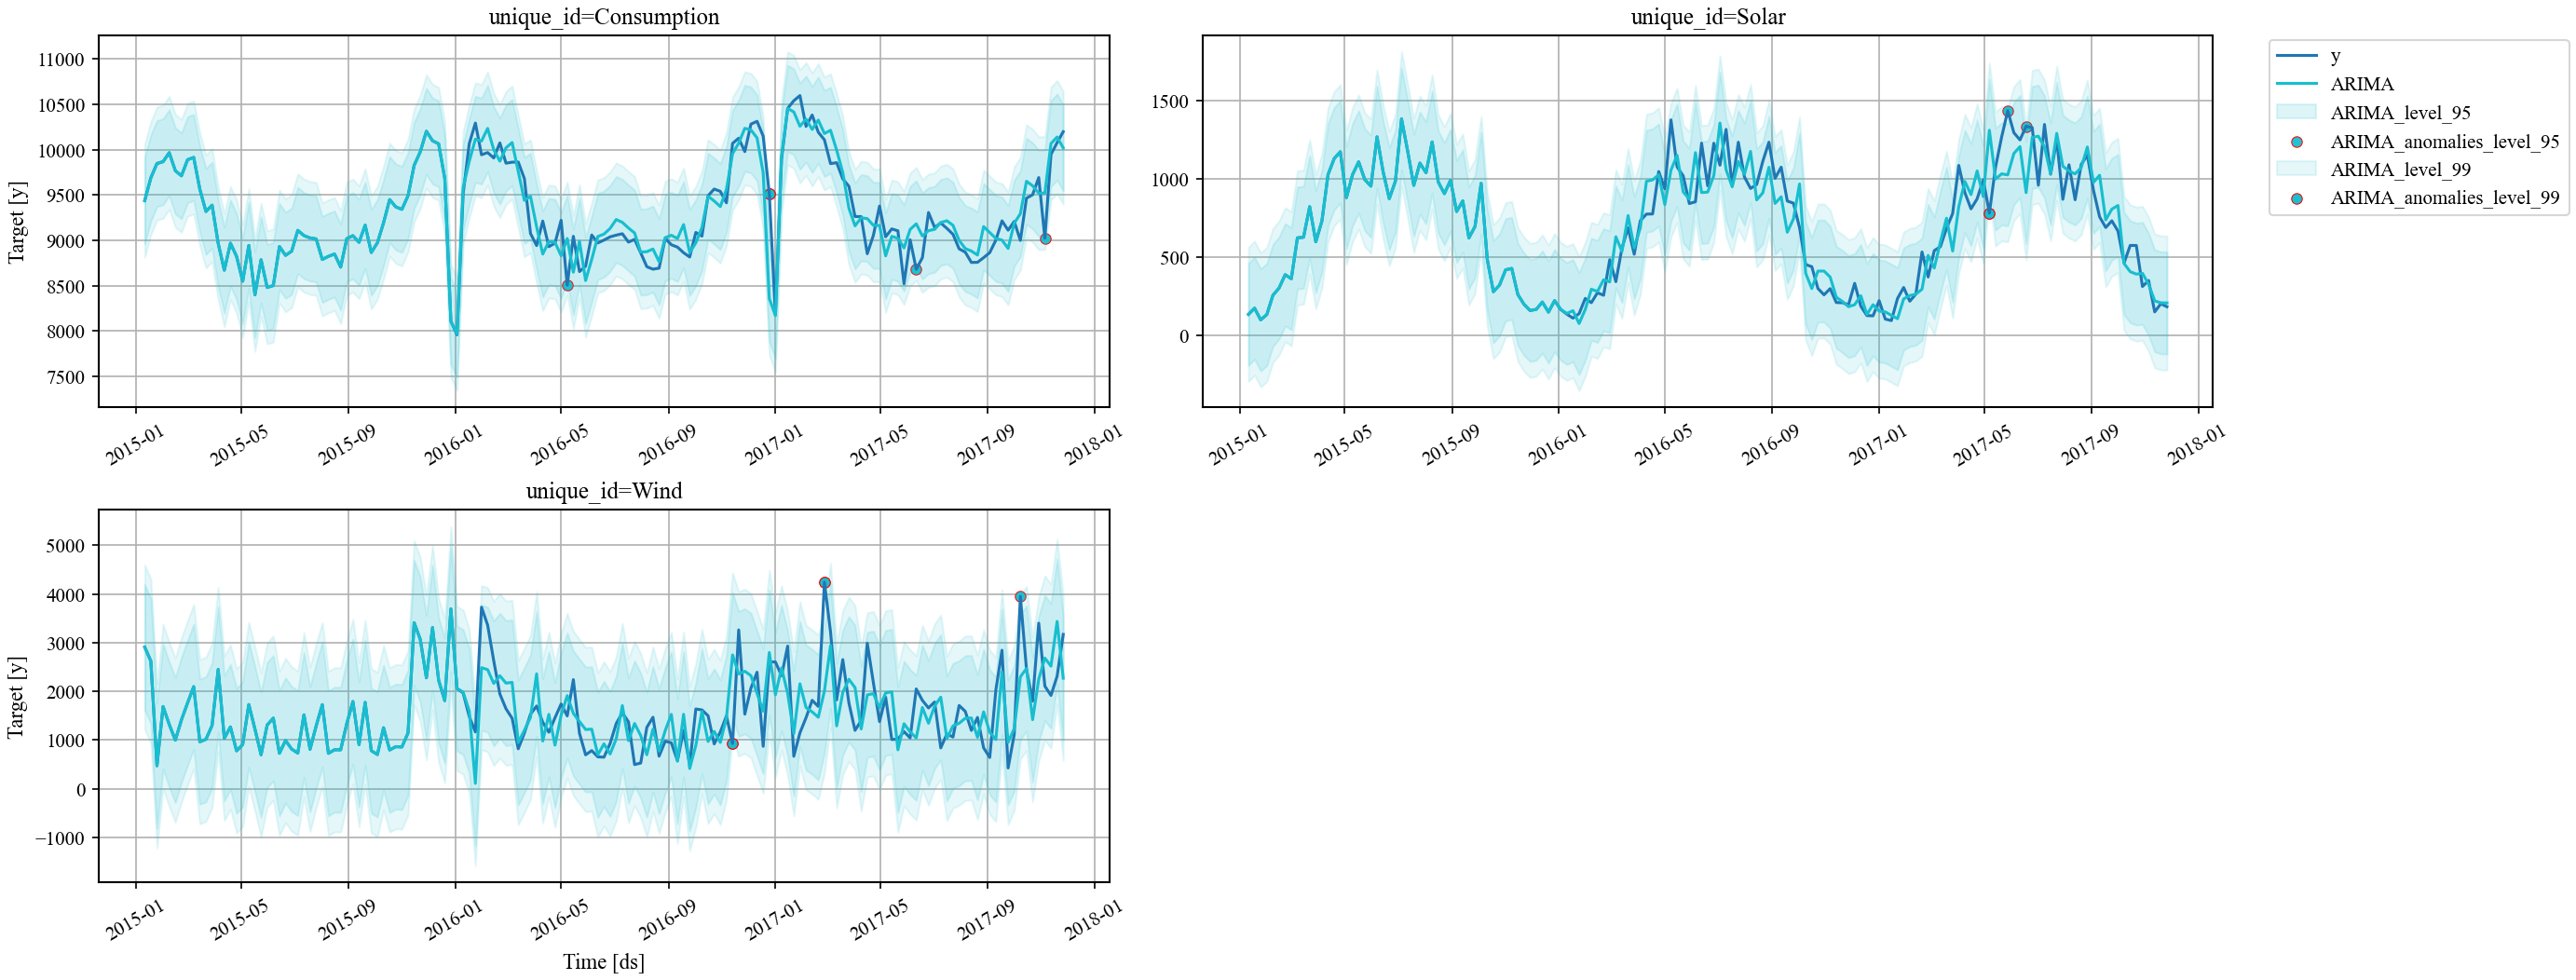

In [45]:
plot_series(forecasts_df=insample_forecasts,
            models = ['ARIMA'],
            level=LEVELS, 
            plot_anomalies=True)

## ДОПОЛНИТЕЛЬНО

### некоторые аугментации искажением

In [ ]:
df_addtitive_shock = add_additive_shock(
    df_train,
    shock_date='2015-03-01',
    shock_strength=1.5,   # 1.5 * IQR — сильный шок
    recovery_offset='12W',   # 12 недель восстановления
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_addtitive_shock, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_imbalance_by_quantile(
    df_train,
    target_seasonal_phases=list(range(20,32)),   # летние недели
    season_length=SEASON,
    imbalance_percent=45.0,
    direction='reduce',
    start_date='2015-01-01',
    duration_offset='2Y', 
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_local_volatility_spike(
    df_train,
    spike_start='2015-04-01',
    duration_offset='16W',
    noise_percent=50.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result =  add_asymmetric_shock(
    df_train,
    shock_start='2015-03-01',
    recovery_offset='12W',
     drop_percent=40.0,
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_signal_degradation(
    df_train,
    degradation_start='2015-01-01',
    duration_offset='52W',      # ← offset-строка вместо weeks
    final_snr_ratio=0.1,
    freq=FREQ,                  # ← обязательная частота
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_seasonal_phase_shift(
    df_train,
    phase_shift_steps=4,
    season_length=SEASON,          # используется только для документации
    start_date='2015-01-01',
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_trend_break(
    df_train,
    break_date='2016-01-01',
    trend_change_per_step=-33.5,
    duration_offset='1Y',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
holidays = [
    '2016-10-24', '2016-10-25', '2016-10-26',
    '2017-10-24', '2017-10-25', '2017-10-26',
    '2018-10-24', '2018-10-25', '2018-10-26',
    '2019-10-24', '2019-10-25', '2019-10-26',
]

df_result = add_seasonal_regressors_effect(
    df_train,
    event_dates=holidays,
    effect_percent=65.0,
    direction='spike',        # снижение активности
    window_radius=4,        # включая день до и после
    freq=FREQ,
    reference='pre_event'
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_sensor_drift(
    df_train,
    drift_start='2016-01-01',
    duration_offset='1Y',
    drift_percent=65.0,
    profile='saturation',
    freq=FREQ
)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_distribution_shift(df_train, 
                                shift_start='2016-04-01', 
                                shift_percent=35.0, 
                                stat='median', 
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_variance_expansion(df_train, 
                                expansion_start='2016-04-01', 
                                   duration_offset='1Y',
                                expansion_factor=2.5,
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

In [ ]:
df_result = add_skewness_shift(df_train, 
                                skew_start='2016-04-01', 
                                   duration_offset='1Y',
tail='right',              # 'right' или 'left'
    intensity=2.3,             # сила искажения (0–1)
                                freq=FREQ)

In [ ]:
n_rows = df_train['unique_id'].nunique()
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)

plot_series(forecasts_df=df_result, 
            ax = ax,
            palette='tab10')

####  ЕЩЕ Беггинг

In [ ]:
import numpy as np
import pandas as pd
from typing import List

def bagging_forecast(
    sf,
    df_train: pd.DataFrame,
    h: int,
    level: List[int],
    n_bags: int = 10,
    window_size: int = None,
    min_train_length: int = 52,
    id_col: str = 'unique_id',
    time_col: str = 'ds',
    target_col: str = 'y'
) -> pd.DataFrame:
    """
    Бэггинг через скользящие окна с использованием готового StatsForecast.
    
    Возвращает DataFrame с колонками:
        <model_alias>_bagged, <model_alias>_bagged-lo-X, <model_alias>_bagged-hi-X
    """
    # Получаем alias моделей из sf
    model_aliases = [getattr(m, 'alias', type(m).__name__) for m in sf.models]
    
    all_uids = df_train[id_col].unique()
    total_points_per_series = len(df_train) // len(all_uids)
    
    if window_size is None:
        window_size = max(min_train_length, total_points_per_series - 26)
    
    bag_forecasts = []
    
    for i in range(n_bags):
        # Случайное окно: сдвиг начала
        max_start = total_points_per_series - window_size
        if max_start <= 0:
            start_idx = 0
        else:
            start_idx = np.random.randint(0, max_start + 1)
        
        # Выбираем последние N точек после start_idx
        df_bag = df_train.groupby(id_col).apply(
            lambda x: x.iloc[start_idx:start_idx + window_size]
        ).reset_index(drop=True)
        
        if len(df_bag) < len(all_uids) * min_train_length:
            continue
        
        try:
            fcst = sf.forecast(df=df_bag, h=h, level=level)
            # Переименовываем колонки: добавляем _bag_i
            rename_map = {}
            for alias in model_aliases:
                rename_map[alias] = f"{alias}_bag_{i}"
                for l in level:
                    lo_key = f"{alias}-lo-{l}"
                    hi_key = f"{alias}-hi-{l}"
                    if lo_key in fcst.columns:
                        rename_map[lo_key] = f"{alias}_bag_{i}-lo-{l}"
                    if hi_key in fcst.columns:
                        rename_map[hi_key] = f"{alias}_bag_{i}-hi-{l}"
            fcst = fcst.rename(columns=rename_map)
            bag_forecasts.append(fcst)
        except Exception as e:
            print(f"Bag {i} failed: {e}")
            continue
    
    if not bag_forecasts:
        raise RuntimeError("No successful bags")
    
    # Объединяем все бэги
    merged = bag_forecasts[0]
    for fcst in bag_forecasts[1:]:
        merged = merged.merge(fcst, on=['unique_id', 'ds'], how='outer')
    
    # Финальный результат
    result = merged[['unique_id', 'ds']].copy()
    
    # Для каждой модели — агрегируем по бэгам
    for alias in model_aliases:
        # Точечные прогнозы
        point_cols = [f"{alias}_bag_{i}" for i in range(len(bag_forecasts)) 
                      if f"{alias}_bag_{i}" in merged.columns]
        if point_cols:
            result[f"{alias}_bagged"] = merged[point_cols].median(axis=1)
        
        # Интервалы
        for l in level:
            lo_cols = [f"{alias}_bag_{i}-lo-{l}" for i in range(len(bag_forecasts)) 
                       if f"{alias}_bag_{i}-lo-{l}" in merged.columns]
            hi_cols = [f"{alias}_bag_{i}-hi-{l}" for i in range(len(bag_forecasts)) 
                       if f"{alias}_bag_{i}-hi-{l}" in merged.columns]
            if lo_cols:
                result[f"{alias}_bagged-lo-{l}"] = merged[lo_cols].median(axis=1)
            if hi_cols:
                result[f"{alias}_bagged-hi-{l}"] = merged[hi_cols].median(axis=1)
    
    return result

In [ ]:
# У вас уже есть:
# sf = StatsForecast(models=[...], freq=FREQ)

# Запуск бэггинга
fcst_bagged = bagging_forecast(
    sf=sf,
    df_train=df_train,
    h=FH,
    level=[90],
    n_bags=5,
    window_size=2*SEASON,  # ~2 года
    min_train_length=SEASON
)

 

# Оценка
eval_bagged = df_test.merge(fcst_bagged, on=['unique_id', 'ds'])
metrics_bagged = evaluate(
    df=eval_bagged,
    metrics=metrics,
    train_df=df_train,
    level=[90]
)
metrics_bagged

In [ ]:
# Визуализация для MSTL
plot_series_v2(
    df_train,
    forecasts_df=fcst_bagged,
    level=[90]
)
